# Covariance inspection (config 1)

Loads a config-1 aggregates H5 (electron + ion TOF, plus GMD
aggregates) and forms two quantities per GMD bin:

  * **Electron–ion covariance**:
      `Cov(D, C) = <DtC> − <D><C>ᵀ`  shape `(n_tof, n_tof_i)`

  * **Partial covariance (controlling for GMD)**:
      `Cov(D, C | G) = Cov(D, C) − Cov(D, G) · Cov(G, C) / Var(G)`

    where `G` is the per-shot scalar GMD. The correction subtracts the
    linear common-mode signal that both detectors inherit from
    pulse-energy fluctuations; what's left is the photon-energy /
    correlated-emission signature that survives intensity normalisation.

In [38]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt

import config
from compute_aggregates import load_aggregates

%matplotlib inline

## Parameters

In [39]:
AGGREGATES_FILE = config.COMBINED_DIR / "glycine_delay_scan_150C_272.0eV_aggregates.h5"
CLIM_PERCENTILE = 99.0

## Load

In [40]:
agg = load_aggregates(AGGREGATES_FILE)
assert agg.config == 1, "This notebook expects a config-1 aggregates file."

print(f"file        : {AGGREGATES_FILE}")
print(f"config      : {agg.config}")
print(f"mode        : {agg.mode}")
print(f"n_gmd_bins  : {agg.n_gmd_bins}")
print(f"n_tof  (e)  : {agg.n_tof}    ({agg.tof_edges[0]:.0f} .. {agg.tof_edges[-1]:.0f} 100 ps)")
print(f"n_tof_i     : {agg.n_tof_i}  ({agg.ion_tof_edges[0]:.0f} .. {agg.ion_tof_edges[-1]:.0f} 100 ps)")
print(f"shots / bin : {agg.n_per_bin}")
print(f"G per bin   : {np.round(agg.G, 3)}")
print(f"Var(G)/bin  : {np.round(agg.var_G, 4)}")

file        : /home/kaiyu/glycine26/11022188/processed/combined/glycine_WL_scan_270.0eV_aggregates.h5
config      : 1
mode        : spectral
n_gmd_bins  : 7
n_tof  (e)  : 1999    (0 .. 40000 100 ps)
n_tof_i     : 1999  (0 .. 40000 100 ps)
shots / bin : [ 3012  5700  8817 15279 27365 33344 50532]
G per bin   : [0.031 0.075 0.148 0.3   0.59  1.147 2.208]
Var(G)/bin  : [0.0002 0.0002 0.0008 0.0033 0.013  0.0422 0.1919]


## Compute covariances per bin

Vectorised over the GMD axis. Shapes:

    cov_DC          (n_gmd, n_tof,  n_tof_i)
    cov_DG          (n_gmd, n_tof)
    cov_GC          (n_gmd, n_tof_i)
    cov_DC_partial  (n_gmd, n_tof,  n_tof_i)

In [41]:
# Direct electron-ion covariance.
cov_DC = agg.DtC - agg.D[..., :, None] * agg.C[..., None, :]

# Covariances of each spectrum with the scalar GMD per bin.
cov_DG = agg.DtG - agg.D * agg.G[..., None]
cov_GC = agg.CtG - agg.C * agg.G[..., None]

var_G  = agg.var_G                                             # (n_gmd,)
safe_var = np.where(var_G > 0, var_G, np.nan)

# Partial: subtract the rank-1 GMD-driven correction.
correction = (cov_DG[..., :, None] * cov_GC[..., None, :]) / safe_var[..., None, None]
cov_DC_partial = cov_DC - correction

# Quick numerical summary per bin.
print(f"{'bin':>3}  {'n':>8}  {'<G>':>7}  {'Var(G)':>9}  "
      f"{'|Cov(D,C)|':>12}  {'|partial|':>12}  {'ratio':>6}")
for b in range(agg.n_gmd_bins):
    if agg.n_per_bin[b] == 0:
        continue
    cov_n      = float(np.linalg.norm(cov_DC[b]))
    cov_part_n = float(np.linalg.norm(cov_DC_partial[b]))
    print(f"{b:>3}  {int(agg.n_per_bin[b]):>8d}  "
          f"{agg.G[b]:>7.3f}  {var_G[b]:>9.3e}  "
          f"{cov_n:>12.3e}  {cov_part_n:>12.3e}  "
          f"{cov_part_n / cov_n if cov_n else float('nan'):>6.3f}")

bin         n      <G>     Var(G)    |Cov(D,C)|     |partial|   ratio
  0      3012    0.031  1.730e-04     2.403e-03     2.402e-03   0.999
  1      5700    0.075  2.010e-04     1.962e-03     1.962e-03   1.000
  2      8817    0.148  8.495e-04     2.427e-03     2.427e-03   1.000
  3     15279    0.300  3.318e-03     3.010e-03     3.003e-03   0.998
  4     27365    0.590  1.296e-02     4.484e-03     4.366e-03   0.974
  5     33344    1.147  4.222e-02     8.610e-03     8.125e-03   0.944
  6     50532    2.208  1.919e-01     1.585e-02     1.332e-02   0.841


## Electron–ion covariance per GMD bin

Each panel: rows = eTOF bins, columns = ion-TOF bins. Diverging
colormap; the colour scale is the 99th percentile of `|cov|` per
panel so a single hot pair doesn't dominate.

In [55]:
def _grid(n):
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    return rows, cols

def _plot_cov_grid(matrices, title, xlim=None, ylim=None):
    rows, cols = _grid(agg.n_gmd_bins)
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.6 * rows))
    axes_flat = np.atleast_1d(axes).ravel()

    extent = [
        agg.ion_tof_edges[0], agg.ion_tof_edges[-1],
        agg.tof_edges[0], agg.tof_edges[-1]
    ]

    for b in range(agg.n_gmd_bins):
        ax = axes_flat[b]
        M = matrices[b]

        if not np.isfinite(M).any():
            ax.set_title(f"bin {b} (empty)")
            ax.axis("off")
            continue

        vmax = float(np.nanpercentile(np.abs(M), CLIM_PERCENTILE)) or 1.0
        im = ax.imshow(
            M,
            origin="lower",
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            extent=extent,
            aspect="auto",
        )

        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.set_title(
            f"GMD [{agg.gmd_edges[b]:.2f}, {agg.gmd_edges[b+1]:.2f})\n"
            f"n={int(agg.n_per_bin[b])}",
            fontsize=10,
        )
        ax.set_xlabel("Ion TOF (100 ps)")
        ax.set_ylabel("e⁻ TOF (100 ps)")
        fig.colorbar(im, ax=ax, fraction=0.046)

    for ax in axes_flat[agg.n_gmd_bins:]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()



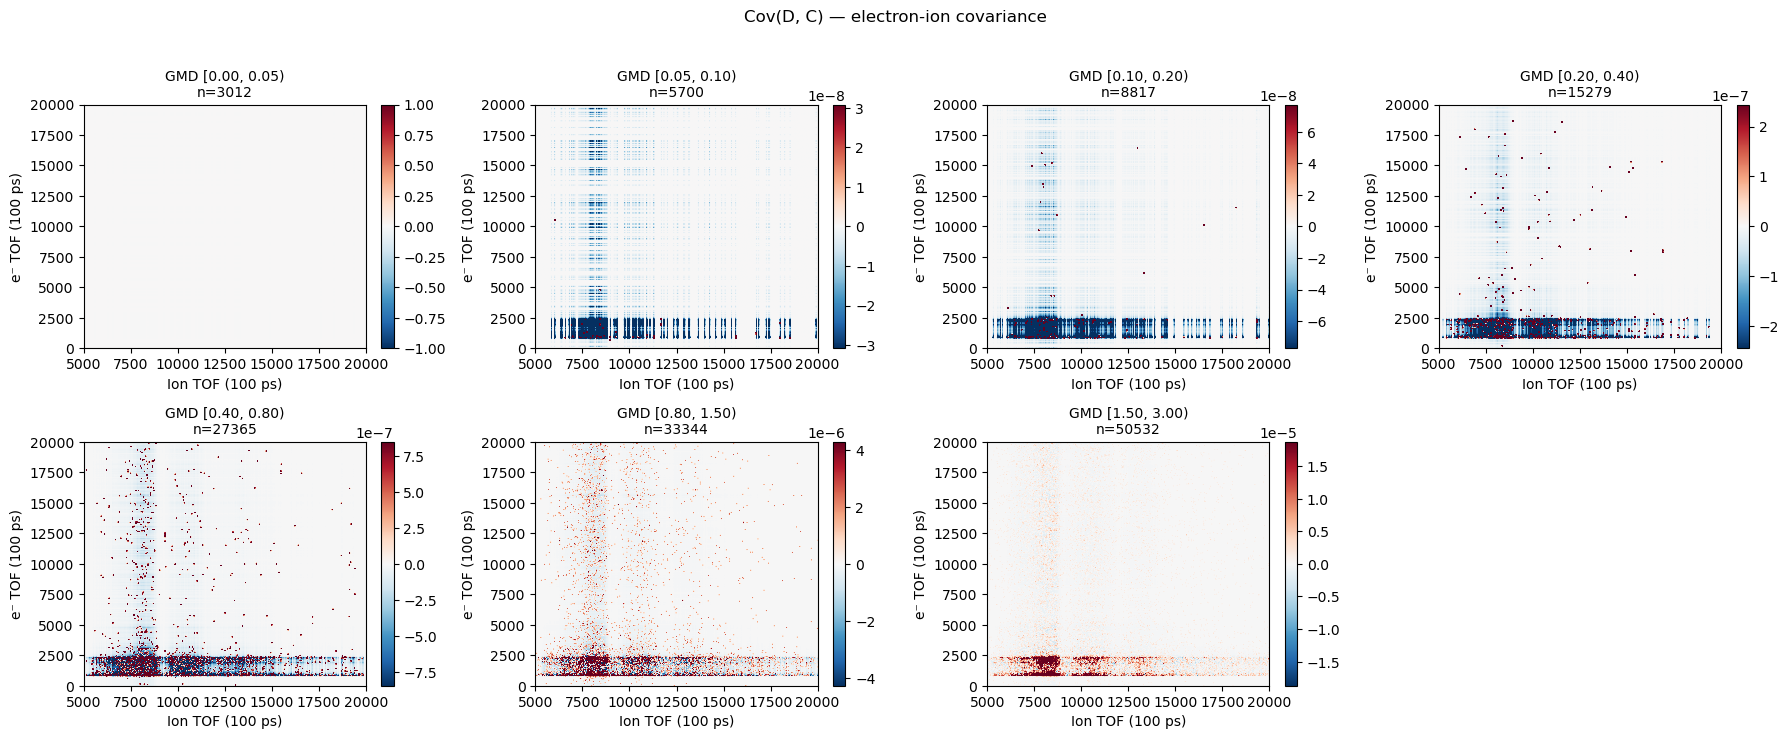

In [56]:
_plot_cov_grid(
    cov_DC,
    "Cov(D, C) — electron-ion covariance",
    xlim=(5000, 20000),   # ion axis
    ylim=(0, 20000),   # electron axis
)

## Partial covariance `Cov(D, C | G)`

Same panels, but with the GMD-driven common-mode subtracted via
`Cov(D, G) Cov(G, C)ᵀ / Var(G)`. Features that remain are not
explained by linear correlations with pulse energy.

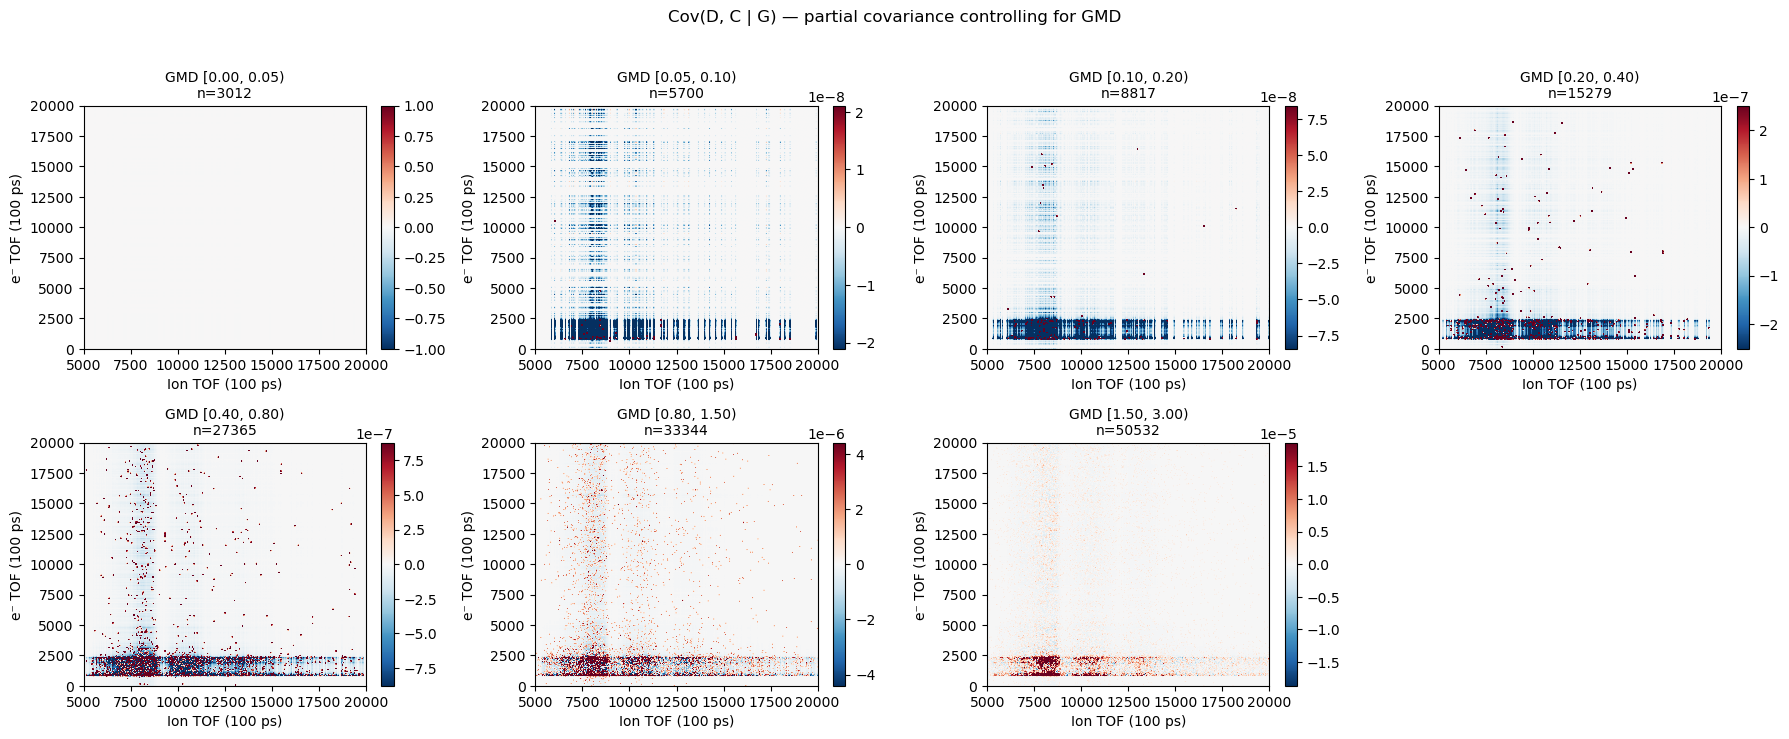

In [57]:
_plot_cov_grid(cov_DC_partial, 
               "Cov(D, C | G) — partial covariance controlling for GMD",     
               xlim=(5000, 20000),   # ion axis
               ylim=(0, 20000),   # electron axis
              )

## Common-mode correction

What was removed: the GMD-driven rank-1 contribution
`Cov(D, G) ⊗ Cov(G, C) / Var(G)`. This is what would dominate if
the apparent electron–ion correlation were driven entirely by shared
pulse-energy fluctuations rather than intrinsic two-particle physics.

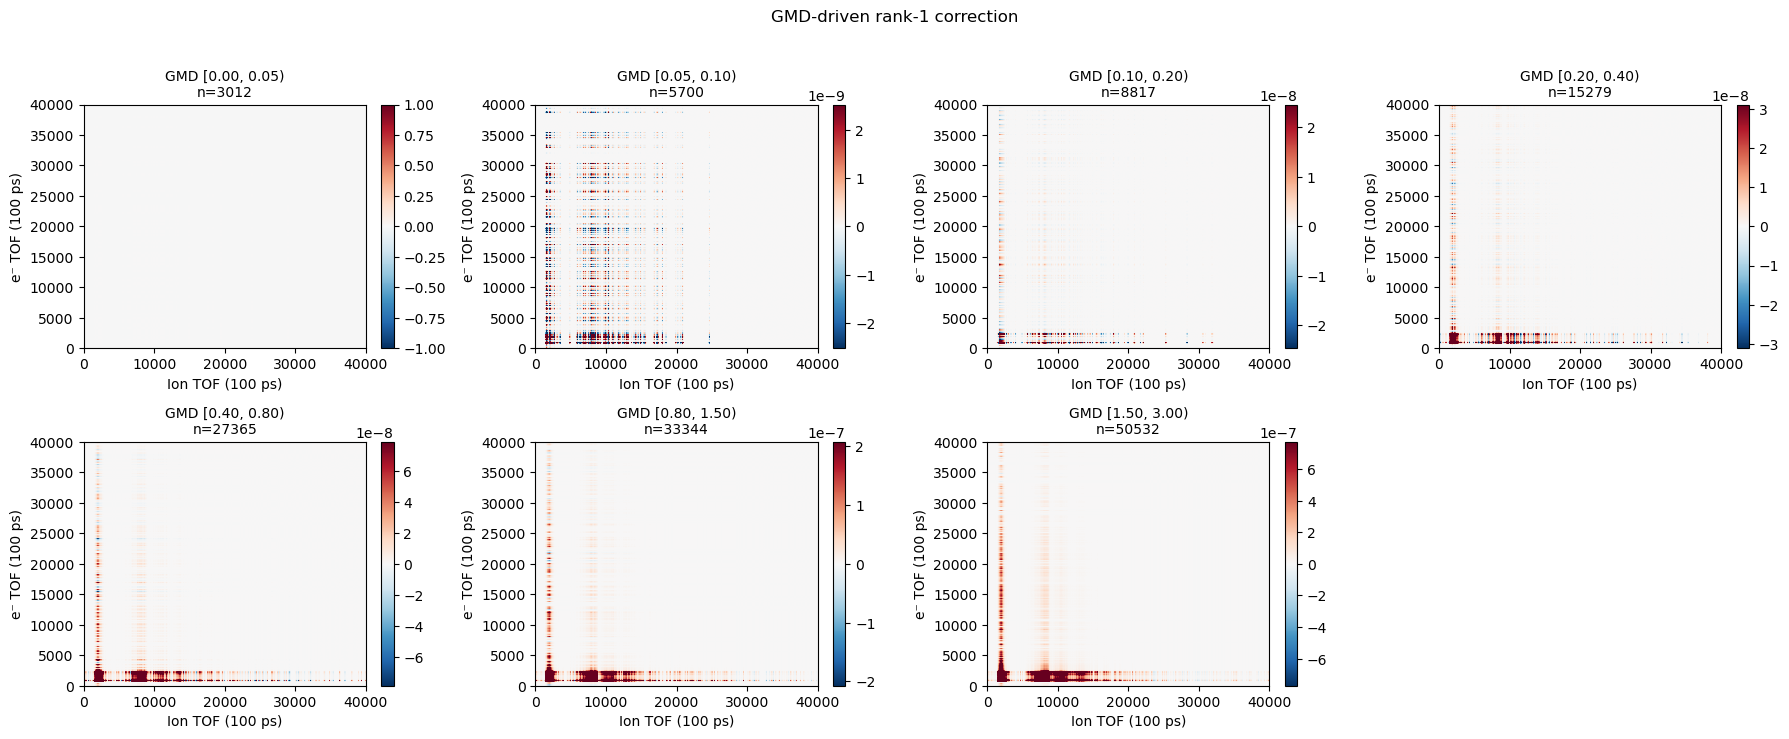

In [47]:
_plot_cov_grid(correction, "GMD-driven rank-1 correction")

## Electron-electron covariance per GMD bin

Same idea as the electron–ion plots above, but now both axes are
the eTOF axis. The matrices are square and symmetric.

  * **Raw**: `Cov(D, D) = <DtD> − <D><D>ᵀ`
  * **Partial**: `Cov(D, D | G) = Cov(D, D) − Cov(D, G) Cov(D, G)ᵀ / Var(G)`

The diagonal of the raw matrix is the per-bin variance of each eTOF
bin; off-diagonal entries are co-fluctuations across TOF bins.

In [ ]:
# Electron-electron covariance per GMD bin.
cov_DD = agg.DtD - agg.D[..., :, None] * agg.D[..., None, :]

# Partial: subtract the rank-1 GMD-driven correction.
correction_DD = (cov_DG[..., :, None] * cov_DG[..., None, :]) / safe_var[..., None, None]
cov_DD_partial = cov_DD - correction_DD

print(f"{'bin':>3}  {'n':>8}  {'<G>':>7}  "
      f"{'|Cov(D,D)|':>12}  {'|partial|':>12}  {'ratio':>6}")
for b in range(agg.n_gmd_bins):
    if agg.n_per_bin[b] == 0:
        continue
    cov_n      = float(np.linalg.norm(cov_DD[b]))
    cov_part_n = float(np.linalg.norm(cov_DD_partial[b]))
    print(f"{b:>3}  {int(agg.n_per_bin[b]):>8d}  "
          f"{agg.G[b]:>7.3f}  "
          f"{cov_n:>12.3e}  {cov_part_n:>12.3e}  "
          f"{cov_part_n / cov_n if cov_n else float('nan'):>6.3f}")

In [ ]:
def _plot_cov_grid_ee(matrices, title, lim=None):
    rows, cols = _grid(agg.n_gmd_bins)
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.6 * rows))
    axes_flat = np.atleast_1d(axes).ravel()

    extent = [agg.tof_edges[0], agg.tof_edges[-1],
              agg.tof_edges[0], agg.tof_edges[-1]]

    for b in range(agg.n_gmd_bins):
        ax = axes_flat[b]
        M = matrices[b]
        if not np.isfinite(M).any():
            ax.set_title(f"bin {b} (empty)")
            ax.axis("off")
            continue
        vmax = float(np.nanpercentile(np.abs(M), CLIM_PERCENTILE)) or 1.0
        im = ax.imshow(M, origin="lower", cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax, extent=extent, aspect="auto")
        if lim is not None:
            ax.set_xlim(*lim)
            ax.set_ylim(*lim)
        ax.set_title(
            f"GMD [{agg.gmd_edges[b]:.2f}, {agg.gmd_edges[b+1]:.2f})\n"
            f"n={int(agg.n_per_bin[b])}",
            fontsize=10,
        )
        ax.set_xlabel("e⁻ TOF (100 ps)")
        ax.set_ylabel("e⁻ TOF (100 ps)")
        fig.colorbar(im, ax=ax, fraction=0.046)

    for ax in axes_flat[agg.n_gmd_bins:]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


_plot_cov_grid_ee(cov_DD,
                  "Cov(D, D) — electron-electron covariance",
                  lim=(0, 20000))

### Cov(D, D | G) — partial electron-electron covariance

Same matrices but with the GMD-driven rank-1 component
`Cov(D, G) Cov(D, G)ᵀ / Var(G)` removed. What remains is the
electron-electron coincidence signal that survives intensity
normalisation.

In [ ]:
_plot_cov_grid_ee(cov_DD_partial,
                  "Cov(D, D | G) — partial electron-electron covariance",
                  lim=(0, 20000))